In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import platform
from matplotlib.patches import Ellipse
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import chi2
import matplotlib.transforms as transforms
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.interpolate import interp1d
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import warnings

In [2]:
# 设置全局字体大小
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# ========== 在这里添加辅助函数 ==========
def add_concentration_unit(label):
    """为浓度数值添加mM单位"""
    try:
        # 尝试转换为浮点数，如果成功说明是浓度值
        float_val = float(label)
        return f"{float_val} mM"
    except (ValueError, TypeError):
        # 如果转换失败，保持原样
        return str(label)
# ======================================

In [3]:
# 1.数据准备
# 读取Excel数据
data = pd.read_excel('AA_data.xlsx', sheet_name='AA')
data.head()

,Potential,0.25,1,2.5,5
0,-0.398,-1.571000e-05,-0.000012,-1.635000e-05,-0.000020
1,-0.396,-1.102000e-05,-0.000007,-1.031000e-05,-0.000013
2,-0.394,-6.890000e-06,-0.000002,-5.148000e-06,-0.000008
3,-0.392,-3.326000e-06,0.000002,-8.059000e-07,-0.000003
4,-0.390,-1.601000e-07,0.000006,2.943000e-06,0.000001


In [4]:
# 参数设置
n_concentrations = len(data.columns) - 1  # 第一列是Potential
concentrations = data.columns[1:].values
potential = data.iloc[:, 0].values

voltage_increment = 0.002  # 您的采样间隔
forward_points = len(np.arange(-0.4, 1.1001, voltage_increment))  # 正向扫描点数
backward_points = len(np.arange(1.1, -0.4001, -voltage_increment))  # 反向扫描点数
full_cycle_points = forward_points + backward_points - 1
print(f"理论完整循环点数: {full_cycle_points}")

理论完整循环点数: 1501


In [5]:
# 检查实际数据
actual_points = len(data)
print(f"实际数据点数: {actual_points}")
print(f"余数: {actual_points % full_cycle_points}")

n_cycles = actual_points // full_cycle_points
remaining_points = actual_points % full_cycle_points

# 获取浓度/分组标签
concentrations = data.columns[1:].values
print(f"检测到的浓度/分组标签: {concentrations}")

# 数据重组
X_list = []
y_list = []
y_original_labels = []  # 保存原始标签

for cycle_idx in range(n_cycles):
    start = cycle_idx * full_cycle_points
    end = (cycle_idx + 1) * full_cycle_points
    
    # 检查是否超出数据范围
    if end > len(data):
        break
        
    for conc in concentrations:
        # 直接使用列名作为标签，不尝试转换为浮点数
        X_list.append(data[conc].iloc[start:end].values)
        y_list.append(conc)# 直接使用原始列名  
        y_original_labels.append(conc)

X = np.array(X_list)
y_labels = np.array(y_list)
y_original = np.array(y_original_labels)

print(f"生成的样本数: {len(X_list)}")
print(f"唯一标签: {np.unique(y_labels)}")

# 处理不完整循环部分（如果有）
if remaining_points > 0 and n_cycles * full_cycle_points < len(data):
    print(f"处理不完整循环，剩余点数: {remaining_points}")
    
    start_partial = n_cycles * full_cycle_points
    X_partial_list = []
    y_partial_list = []
    y_original_partial = []
    
    for conc in concentrations:
        partial_data = data[conc].iloc[start_partial:].values
        
        if len(partial_data) >= 2:  # 至少需要2个点才能插值
            # 对不完整循环进行插值补齐
            x_new = np.linspace(0, 1, full_cycle_points)
            x_old = np.linspace(0, 1, len(partial_data))
            
            try:
                interpolator = interp1d(x_old, partial_data, kind='linear', 
                                      fill_value='extrapolate')
                partial_full = interpolator(x_new)
                X_partial_list.append(partial_full)
                y_partial_list.append(conc)
                y_original_partial.append(conc)
            except Exception as e:
                print(f"插值失败 {conc}: {e}")
                continue
    
    if X_partial_list:
        X_partial = np.array(X_partial_list)
        X = np.vstack([X, X_partial])
        y_labels = np.concatenate([y_labels, y_partial_list])
        y_original = np.concatenate([y_original, y_original_partial])
        print(f"添加了 {len(X_partial_list)} 个不完整循环样本")

print(f"原始数据形状: {X.shape}")

实际数据点数: 224999
余数: 1350
检测到的浓度/分组标签: [0.25 1 2.5 5]
生成的样本数: 596
唯一标签: [0.25 1.   2.5  5.  ]
处理不完整循环，剩余点数: 1350
添加了 4 个不完整循环样本
原始数据形状: (600, 1501)


In [6]:
# 2. 创建大类标签函数
def create_main_group_labels(labels):
    """将详细标签转换为大类标签"""
    main_groups = []
    for label in labels:
        if '_' in str(label):
            main_group = str(label).split('_')[0]  # 取_前面的部分作为大类
        else:
            main_group = str(label)  # 如果没有_，使用原标签
        main_groups.append(main_group)
    return np.array(main_groups)

# 创建大类标签
y_main_groups = create_main_group_labels(y_original)
print(f"原始标签示例: {y_original[:10]}")
print(f"大类标签示例: {y_main_groups[:10]}")
print(f"唯一大类: {np.unique(y_main_groups)}")

原始标签示例: [0.25 1.   2.5  5.   0.25 1.   2.5  5.   0.25 1.  ]
大类标签示例: ['0.25' '1.0' '2.5' '5.0' '0.25' '1.0' '2.5' '5.0' '0.25' '1.0']
唯一大类: ['0.25' '1.0' '2.5' '5.0']


In [7]:
# 3. 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 验证维度
print(f"最终数据形状: {X_scaled.shape}")
print(f"样本数: {X_scaled.shape[0]}, 特征数: {X_scaled.shape[1]}")

# 检查数据质量
print("缺失值数量:", np.isnan(X_scaled).sum())
print("无限值数量:", np.isinf(X_scaled).sum())

最终数据形状: (600, 1501)
样本数: 600, 特征数: 1501
缺失值数量: 0
无限值数量: 0



LDA 分析
大类类别数: 4
各类别样本分布:
  0.25: 150 个样本
  1.0: 150 个样本
  2.5: 150 个样本
  5.0: 150 个样本
LDA降维后形状: (600, 3)
LDA解释方差比: [0.98485164 0.01317184 0.00197652]

3D LDA可视化
3D LDA分析成功！提取了3个判别成分
3D LDA解释方差比: [0.98485164 0.01317184 0.00197652]
X轴刻度: [-180. -160. -140. -120. -100.  -80.  -60.  -40.  -20.    0.   20.   40.
   60.   80.  100.  120.  140.  160.  180.  200.  220.]
Y轴刻度: [-30. -20. -10.   0.  10.  20.]
Z轴刻度: [-10.   0.  10.]
Z label text: LD3 (0.2%)


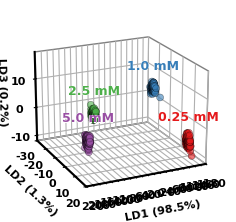

In [8]:
# 4. LDA降维和分析
print("\n" + "="*50)
print("LDA 分析")
print("="*50)

# 使用大类标签进行LDA
label_encoder_main = LabelEncoder()
y_main_encoded = label_encoder_main.fit_transform(y_main_groups)

print(f"大类类别数: {len(label_encoder_main.classes_)}")
print("各类别样本分布:")
for i, class_name in enumerate(label_encoder_main.classes_):
    count = np.sum(y_main_encoded == i)
    print(f"  {class_name}: {count} 个样本")

# 检查LDA可行性
n_classes_main = len(np.unique(y_main_encoded))  # 添加这一行
n_samples = X_scaled.shape[0]

if n_samples <= n_classes_main:
    print(f"警告: 样本数({n_samples})不足类别数({n_classes_main})，LDA可能无法正常工作")
else:
    X_for_lda = X_scaled

# 执行LDA
lda = LDA(n_components=min(n_classes_main-1, X_for_lda.shape[1]))
X_lda = lda.fit_transform(X_for_lda, y_main_encoded)

print(f"LDA降维后形状: {X_lda.shape}")
print(f"LDA解释方差比: {lda.explained_variance_ratio_}")

# ========== 3D LDA可视化 ==========
print("\n" + "="*50)
print("3D LDA可视化")
print("="*50)

# 检查是否可以提取3个成分
n_components_3d = min(3, n_classes_main - 1, X_for_lda.shape[1])  # 现在 n_classes_main 已定义
if n_components_3d >= 2:
    try:
        lda_3d = LDA(n_components=n_components_3d, solver='svd')
        X_lda_3d = lda_3d.fit_transform(X_for_lda, y_main_encoded)
        print(f"3D LDA分析成功！提取了{n_components_3d}个判别成分")
        print(f"3D LDA解释方差比: {lda_3d.explained_variance_ratio_}")
    except Exception as e:
        print(f"3D LDA失败: {str(e)}")
        raise e
else:
    print(f"类别数不足，无法提取3个成分（当前{n_classes_main}个类别）")

# 创建3D可视化图
fig_3d = plt.figure(figsize=(3, 2.5))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# 使用鲜艳的颜色方案
bright_colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', 
                 '#FFFF33', '#A65628', '#F781BF', '#999999', '#66C2A5']
colors_3d = bright_colors[:len(label_encoder_main.classes_)]

# 先绘制散点（低透明度）
for i, class_name in enumerate(label_encoder_main.classes_):
    mask = y_main_encoded == i
    ax_3d.scatter(X_lda_3d[mask, 0], 
                  X_lda_3d[mask, 1], 
                  X_lda_3d[mask, 2],
                  color=colors_3d[i], alpha=0.6, s=25,
                  edgecolors='black', linewidth=0.3, zorder=1)

# ========== 修改：设置整数刻度（逢0、5等） ==========
def get_integer_ticks(min_val, max_val, step=5):
    """生成整数刻度的辅助函数"""
    # 向下取整到最近的step倍数
    start = np.floor(min_val / step) * step
    # 向上取整到最近的step倍数
    end = np.ceil(max_val / step) * step
    # 生成刻度
    ticks = np.arange(start, end + step, step)
    # 过滤掉超出范围的刻度（保留一点点余量）
    ticks = ticks[(ticks >= min_val - step/2) & (ticks <= max_val + step/2)]
    return ticks

# 获取实际数据范围
x_min, x_max = ax_3d.get_xlim()
y_min, y_max = ax_3d.get_ylim()
z_min, z_max = ax_3d.get_zlim()

# 根据数据范围自动选择合适的步长
def get_step(value_range):
    """根据数据范围选择合适的步长"""
    range_abs = abs(value_range)
    if range_abs <= 10:
        return 2
    elif range_abs <= 20:
        return 5
    elif range_abs <= 50:
        return 10
    else:
        return 20

x_step = get_step(x_max - x_min)
y_step = get_step(y_max - y_min)
z_step = get_step(z_max - z_min)

# 生成整数刻度
x_ticks = get_integer_ticks(x_min, x_max, x_step)
y_ticks = get_integer_ticks(y_min, y_max, y_step)
z_ticks = get_integer_ticks(z_min, z_max, z_step)

# 设置X轴刻度
ax_3d.set_xticks(x_ticks)
ax_3d.set_xticklabels([f'{int(tick)}' if tick == int(tick) else f'{tick:.1f}' for tick in x_ticks], 
                      fontweight='bold')

# 设置Y轴刻度
ax_3d.set_yticks(y_ticks)
ax_3d.set_yticklabels([f'{int(tick)}' if tick == int(tick) else f'{tick:.1f}' for tick in y_ticks], 
                      fontweight='bold')

# 设置Z轴刻度
ax_3d.set_zticks(z_ticks)
ax_3d.set_zticklabels([f'{int(tick)}' if tick == int(tick) else f'{tick:.1f}' for tick in z_ticks], 
                      fontweight='bold')

print(f"X轴刻度: {x_ticks}")
print(f"Y轴刻度: {y_ticks}")
print(f"Z轴刻度: {z_ticks}")
# ======================================

# 重新获取更新后的坐标轴范围（因为设置刻度可能改变范围）
x_min, x_max = ax_3d.get_xlim()
y_min, y_max = ax_3d.get_ylim()
z_min, z_max = ax_3d.get_zlim()
x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min

# 计算每个类别的中心点（X, Y坐标）和最高点（用于放置标签）
label_data = []

for i, class_name in enumerate(label_encoder_main.classes_):
    mask = y_main_encoded == i
    points = X_lda_3d[mask]
    
    # 计算类别的中心点（X, Y坐标的中位数）
    center_x = np.median(points[:, 0])
    center_y = np.median(points[:, 1])
    
    # 找到该类别的最高Z值（顶部）
    top_z = np.max(points[:, 2])
    
    # 标签放在该类别最高点的正上方
    label_x = center_x
    label_y = center_y
    label_z = top_z + z_range * 0.12  # 高出散点顶部12%的Z轴范围
    
    # 如果多个类别的标签位置太近，进行水平偏移
    label_data.append({
        'class_name': class_name,
        'label_x': label_x,
        'label_y': label_y,
        'label_z': label_z,
        'center_x': center_x,
        'center_y': center_y,
        'color': colors_3d[i]
    })

# 处理标签水平位置冲突（如果两个类别的标签在X-Y平面太近）
for i in range(len(label_data)):
    for j in range(i+1, len(label_data)):
        dist_xy = np.sqrt((label_data[i]['label_x'] - label_data[j]['label_x'])**2 + 
                         (label_data[i]['label_y'] - label_data[j]['label_y'])**2)
        min_dist = x_range * 0.15  # 最小距离阈值
        
        if dist_xy < min_dist:
            # 如果太近，向两侧移动
            angle = np.arctan2(label_data[j]['label_y'] - label_data[i]['label_y'],
                              label_data[j]['label_x'] - label_data[i]['label_x'])
            offset = (min_dist - dist_xy) / 2
            label_data[i]['label_x'] -= np.cos(angle) * offset
            label_data[i]['label_y'] -= np.sin(angle) * offset
            label_data[j]['label_x'] += np.cos(angle) * offset
            label_data[j]['label_y'] += np.sin(angle) * offset

# 添加文本标签（在最上层，带白色描边）
for data in label_data:
    # 使用辅助函数添加单位
    display_name = add_concentration_unit(data['class_name'])
    # 添加白色描边效果
    for offset in [(0.02, 0, 0), (-0.02, 0, 0), (0, 0.02, 0), (0, -0.02, 0), 
                   (0, 0, 0.02), (0, 0, -0.02)]:
        ax_3d.text(data['label_x'] + offset[0], 
                   data['label_y'] + offset[1], 
                   data['label_z'] + offset[2],
                   display_name, fontsize=9, fontweight='bold',
                   color='white', alpha=0.9, zorder=3,
                   ha='center', va='bottom')
    
    # 添加实际颜色的文本
    ax_3d.text(data['label_x'], data['label_y'], data['label_z'],
               display_name, fontsize=9, fontweight='bold',
               color=data['color'], zorder=3,
               ha='center', va='bottom')

# 设置3D图形标签 - 减小labelpad
if hasattr(lda_3d, 'explained_variance_ratio_'):
    if len(lda_3d.explained_variance_ratio_) >= 3:
        ax_3d.set_xlabel(f'LD1 ({lda_3d.explained_variance_ratio_[0]*100:.1f}%)', 
                        fontsize=8, fontweight='bold', labelpad=-2, color='black')
        ax_3d.set_ylabel(f'LD2 ({lda_3d.explained_variance_ratio_[1]*100:.1f}%)', 
                        fontsize=8, fontweight='bold', labelpad=-2, color='black')
        ax_3d.set_zlabel(f'LD3 ({lda_3d.explained_variance_ratio_[2]*100:.1f}%)', 
                        fontsize=8, fontweight='bold', labelpad=-5, color='black')
    else:
        ax_3d.set_xlabel(f'LD1 ({lda_3d.explained_variance_ratio_[0]*100:.1f}%)', 
                        fontsize=8, fontweight='bold', labelpad=-2, color='black')
        ax_3d.set_ylabel(f'LD2 ({lda_3d.explained_variance_ratio_[1]*100:.1f}%)', 
                        fontsize=8, fontweight='bold', labelpad=-2, color='black')
        ax_3d.set_zlabel('LD3', fontsize=8, fontweight='bold', labelpad=-5, color='black')
else:
    ax_3d.set_xlabel('LD1', fontsize=8, fontweight='bold', labelpad=-2, color='black')
    ax_3d.set_ylabel('LD2', fontsize=8, fontweight='bold', labelpad=-2, color='black')
    ax_3d.set_zlabel('LD3', fontsize=8, fontweight='bold', labelpad=-5, color='black')

# 设置坐标轴刻度和标签 - 减小pad值到最小
ax_3d.tick_params(axis='x', labelsize=8, pad=0, colors='black', direction='in', width=1.2)
ax_3d.tick_params(axis='y', labelsize=8, pad=0, colors='black', direction='in', width=1.2)
ax_3d.tick_params(axis='z', labelsize=8, pad=0, colors='black', direction='in', width=1.2)

# 设置刻度线长度和宽度
ax_3d.xaxis.set_tick_params(length=5, width=1.2)
ax_3d.yaxis.set_tick_params(length=5, width=1.2)
ax_3d.zaxis.set_tick_params(length=5, width=1.2)

# 设置刻度标签的字体加粗
for label in ax_3d.get_xticklabels():
    label.set_fontweight('bold')
for label in ax_3d.get_yticklabels():
    label.set_fontweight('bold')
for label in ax_3d.get_zticklabels():
    label.set_fontweight('bold')

# 设置坐标轴线宽和颜色
ax_3d.xaxis.line.set_linewidth(1.5)
ax_3d.xaxis.line.set_color('black')
ax_3d.yaxis.line.set_linewidth(1.5)
ax_3d.yaxis.line.set_color('black')
ax_3d.zaxis.line.set_linewidth(1.5)
ax_3d.zaxis.line.set_color('black')

# 设置坐标轴
ax_3d.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
ax_3d.xaxis.pane.fill = False
ax_3d.yaxis.pane.fill = False
ax_3d.zaxis.pane.fill = False

# 设置坐标轴面板边框
ax_3d.xaxis.pane.set_edgecolor('black')
ax_3d.yaxis.pane.set_edgecolor('black')
ax_3d.zaxis.pane.set_edgecolor('black')
ax_3d.xaxis.pane.set_linewidth(1)
ax_3d.yaxis.pane.set_linewidth(1)
ax_3d.zaxis.pane.set_linewidth(1)

# 调整Z轴范围，为上方标签留出空间
z_max_new = z_max + z_range * 0.25
ax_3d.set_zlim(z_min, z_max_new)

# 调整视角（俯视角度，便于看到标签在上方）
ax_3d.view_init(elev=20, azim=65)

# 紧凑布局 - 使用更小的边距
plt.subplots_adjust(left=0.15, right=0.95, top=0.90, bottom=0.10)
print("Z label text:", ax_3d.get_zlabel())  # 检查标签文本是否被正确设置
plt.show()

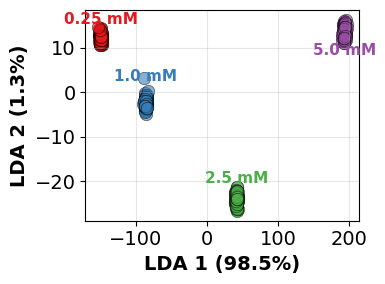

In [9]:
# ========== 继续原有的2D LDA可视化 ==========

# 绘制LDA前两个成分的散点图

# 创建LDA散点图
plt.figure(figsize=(4, 3))

# 使用更鲜明的颜色调色板
bright_colors_2d = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', 
                    '#FFFF33', '#A65628', '#F781BF', '#999999', '#66C2A5']
colors_2d = bright_colors_2d[:len(label_encoder_main.classes_)]

# 存储每个类别的信息
label_positions = []

# 先绘制所有散点（低zorder，让标签在上层）
for i, class_name in enumerate(label_encoder_main.classes_):
    mask = y_main_encoded == i
    x_data = X_lda[mask, 0]
    y_data = X_lda[mask, 1]
    
    plt.scatter(x_data, y_data, 
                c=[colors_2d[i]], 
                alpha=0.6,
                s=80,
                edgecolors='black',
                linewidth=0.5,
                zorder=1)
    
    # 计算类别中心点
    center_x = np.median(x_data)
    center_y = np.median(y_data)
    
    # 计算散点的边界范围
    x_min_data = np.min(x_data)
    x_max_data = np.max(x_data)
    y_min_data = np.min(y_data)
    y_max_data = np.max(y_data)
    
    # 收集所有散点坐标用于碰撞检测
    points_coords = np.column_stack((x_data, y_data))
    
    label_positions.append({
        'name': class_name,
        'center_x': center_x,
        'center_y': center_y,
        'x_min': x_min_data,
        'x_max': x_max_data,
        'y_min': y_min_data,
        'y_max': y_max_data,
        'color': colors_2d[i],
        'points': points_coords,  # 存储所有散点坐标
        'label_x': None,
        'label_y': None
    })

# 获取当前坐标轴范围
ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
x_range = x_max - x_min
y_range = y_max - y_min

# ========== 智能标签位置算法 ==========
def is_point_overlapping_with_scatter(label_x, label_y, points, min_distance=0.5):
    """检查标签点是否与任何散点重叠"""
    if len(points) == 0:
        return False
    # 计算标签点到所有散点的最小距离
    distances = np.sqrt((points[:, 0] - label_x)**2 + (points[:, 1] - label_y)**2)
    return np.min(distances) < min_distance

def is_label_outside_axes(label_x, label_y, margin_ratio=0.02):
    """检查标签是否超出坐标轴范围"""
    x_min_adj = x_min + (x_max - x_min) * margin_ratio
    x_max_adj = x_max - (x_max - x_min) * margin_ratio
    y_min_adj = y_min + (y_max - y_min) * margin_ratio
    y_max_adj = y_max - (y_max - y_min) * margin_ratio
    return not (x_min_adj <= label_x <= x_max_adj and y_min_adj <= label_y <= y_max_adj)

def check_label_overlap_with_others(label_x, label_y, placed_labels, min_label_distance=1.0):
    """检查标签是否与其他已放置的标签重叠"""
    for placed in placed_labels:
        dist = np.sqrt((label_x - placed[0])**2 + (label_y - placed[1])**2)
        if dist < min_label_distance:
            return True
    return False

# 为每个类别寻找最佳标签位置
placed_labels = []  # 存储已放置的标签位置 [(x, y), ...]

for pos in label_positions:
    # 计算散点簇的宽度和高度
    cluster_width = pos['x_max'] - pos['x_min']
    cluster_height = pos['y_max'] - pos['y_min']
    
    # 定义8个候选方向（上、下、左、右、左上、右上、左下、右下）
    directions = [
        (0, 1),     # 上
        (0, -1),    # 下
        (-1, 0),    # 左
        (1, 0),     # 右
        (-0.7, 0.7), # 左上
        (0.7, 0.7),  # 右上
        (-0.7, -0.7), # 左下
        (0.7, -0.7)   # 右下
    ]
    
    # 计算偏移距离（基于簇的大小）
    base_offset_x = cluster_width * 0.6 + x_range * 0.05
    base_offset_y = cluster_height * 0.6 + y_range * 0.05
    
    # 尝试不同距离的偏移
    found_position = False
    best_position = None
    best_score = float('inf')
    
    # 尝试不同的偏移倍数
    for multiplier in [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5]:
        for dx_ratio, dy_ratio in directions:
            # 计算候选位置
            candidate_x = pos['center_x'] + dx_ratio * base_offset_x * multiplier
            candidate_y = pos['center_y'] + dy_ratio * base_offset_y * multiplier
            
            # 检查是否超出坐标轴范围
            if is_label_outside_axes(candidate_x, candidate_y):
                continue
            
            # 检查是否与散点重叠
            if is_point_overlapping_with_scatter(candidate_x, candidate_y, pos['points'], min_distance=0.8):
                continue
            
            # 检查是否与其他标签重叠
            if check_label_overlap_with_others(candidate_x, candidate_y, placed_labels, min_label_distance=1.5):
                continue
            
            # 计算评分（距离中心越近越好）
            distance_to_center = np.sqrt((candidate_x - pos['center_x'])**2 + (candidate_y - pos['center_y'])**2)
            score = distance_to_center
            
            if score < best_score:
                best_score = score
                best_position = (candidate_x, candidate_y)
                found_position = True
        
        if found_position:
            break
    
    # 如果找到了合适的位置，使用它
    if found_position:
        pos['label_x'] = best_position[0]
        pos['label_y'] = best_position[1]
        placed_labels.append(best_position)
    else:
        # 如果没有找到理想位置，使用默认位置（向外偏移）
        # 根据簇的位置选择最佳默认方向
        space_up = y_max - pos['y_max']
        space_down = pos['y_min'] - y_min
        space_right = x_max - pos['x_max']
        space_left = pos['x_min'] - x_min
        
        # 选择空间最大的方向
        max_space = max(space_up, space_down, space_right, space_left)
        
        if max_space == space_up:
            candidate_x = pos['center_x']
            candidate_y = pos['y_max'] + cluster_height * 0.3
        elif max_space == space_down:
            candidate_x = pos['center_x']
            candidate_y = pos['y_min'] - cluster_height * 0.3
        elif max_space == space_right:
            candidate_x = pos['x_max'] + cluster_width * 0.3
            candidate_y = pos['center_y']
        else:
            candidate_x = pos['x_min'] - cluster_width * 0.3
            candidate_y = pos['center_y']
        
        # 确保在坐标轴范围内
        candidate_x = np.clip(candidate_x, x_min + x_range*0.05, x_max - x_range*0.05)
        candidate_y = np.clip(candidate_y, y_min + y_range*0.05, y_max - y_range*0.05)
        
        pos['label_x'] = candidate_x
        pos['label_y'] = candidate_y
        placed_labels.append((candidate_x, candidate_y))

# 第二轮调整：检查并解决残留的重叠问题
max_iterations = 10
for iteration in range(max_iterations):
    any_overlap = False
    
    for i, pos in enumerate(label_positions):
        # 检查与散点的重叠
        if is_point_overlapping_with_scatter(pos['label_x'], pos['label_y'], pos['points'], min_distance=0.6):
            any_overlap = True
            # 微调位置：向外移动
            dx = pos['label_x'] - pos['center_x']
            dy = pos['label_y'] - pos['center_y']
            if dx == 0 and dy == 0:
                dx, dy = 1, 0
            # 归一化并向外移动
            norm = np.sqrt(dx**2 + dy**2)
            dx = dx / norm * (cluster_width * 0.3)
            dy = dy / norm * (cluster_height * 0.3)
            new_x = pos['label_x'] + dx
            new_y = pos['label_y'] + dy
            
            # 确保不超出范围
            new_x = np.clip(new_x, x_min + x_range*0.05, x_max - x_range*0.05)
            new_y = np.clip(new_y, y_min + y_range*0.05, y_max - y_range*0.05)
            
            pos['label_x'] = new_x
            pos['label_y'] = new_y
    
    if not any_overlap:
        break

# ========== 添加文本标签 ==========
for pos in label_positions:
    # 使用辅助函数添加单位
    display_name = add_concentration_unit(pos['name'])
    plt.text(pos['label_x'], pos['label_y'], display_name,
             fontsize=11, fontweight='bold', color=pos['color'],
             ha='center', va='center',
             bbox=None,  # 修改为None，实现完全透明背景 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
             zorder=5)

plt.xlabel(f'LDA 1 ({lda.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14, weight='bold')
plt.ylabel(f'LDA 2 ({lda.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14, weight='bold')

# 同时设置 X 轴和 Y 轴刻度字体大小
plt.tick_params(axis='both', labelsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


随机森林分类 - 大类

----------------------------------------
1. 随机森林分类
----------------------------------------
随机森林准确率: 1.0000

随机森林分类报告:
              precision    recall  f1-score   support

        0.25       1.00      1.00      1.00        45
         1.0       1.00      1.00      1.00        45
         2.5       1.00      1.00      1.00        45
         5.0       1.00      1.00      1.00        45

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



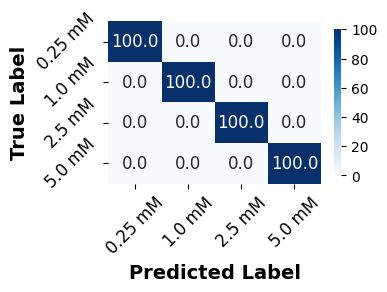

In [10]:
# 5. 基于LDA的随机森林分类（大类）
print("\n" + "="*50)
print("随机森林分类 - 大类")
print("="*50)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y_main_encoded, test_size=0.3, random_state=42, stratify=y_main_encoded
)

# 存储所有模型的结果
models_results = {}

# 1. 随机森林分类
print("\n" + "-"*40)
print("1. 随机森林分类")
print("-"*40)

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"随机森林准确率: {accuracy_rf:.4f}")
print("\n随机森林分类报告:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder_main.classes_))

models_results['Random Forest'] = {
    'model': rf_classifier,
    'y_pred': y_pred_rf,
    'accuracy': accuracy_rf,
    'precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'f1': f1_score(y_test, y_pred_rf, average='weighted')
}

# 绘制随机森林混淆矩阵
plt.figure(figsize=(4, 3))
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_percentage_rf = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis] * 100

# 创建带单位的标签列表
class_names_with_unit = [add_concentration_unit(name) for name in label_encoder_main.classes_]

# 然后在 heatmap 中使用
ax = sns.heatmap(cm_percentage_rf, annot=True, fmt='.1f', cmap='Blues',
                 xticklabels=class_names_with_unit,  # 修改这里
                 yticklabels=class_names_with_unit,  # 修改这里
                 cbar_kws={'shrink': 0.9},
                 annot_kws={'size': 12})

# 修改colorbar字体大小
cbar = ax.collections[0].colorbar  # 获取colorbar对象
#cbar.set_label('Percentage (%)', fontsize=16)  # 修改标签字体
cbar.ax.tick_params(labelsize=10)  # 修改刻度字体

# 设置x轴标签（放大一倍并加粗）
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45)
# 设置y轴标签（放大一倍并加粗）
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=45)

# plt.title(f'Random Forest Confusion Matrix (Accuracy: {accuracy_rf:.2f})', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


----------------------------------------
2. K近邻分类
----------------------------------------
KNN准确率 (K=5): 1.0000

KNN分类报告:
              precision    recall  f1-score   support

        0.25       1.00      1.00      1.00        45
         1.0       1.00      1.00      1.00        45
         2.5       1.00      1.00      1.00        45
         5.0       1.00      1.00      1.00        45

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



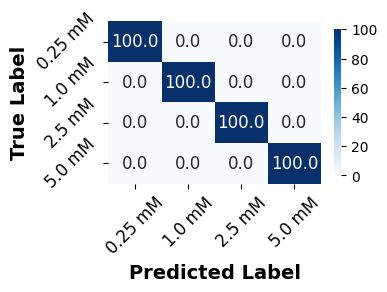

In [11]:
# 2. K近邻分类
print("\n" + "-"*40)
print("2. K近邻分类")
print("-"*40)

knn_best = KNeighborsClassifier(n_neighbors=5)
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN准确率 (K=5): {accuracy_knn:.4f}")
print("\nKNN分类报告:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder_main.classes_))

models_results['KNN'] = {
    'model': knn_best,
    'y_pred': y_pred_knn,
    'accuracy': accuracy_knn,
    'precision': precision_score(y_test, y_pred_knn, average='weighted'),
    'recall': recall_score(y_test, y_pred_knn, average='weighted'),
    'f1': f1_score(y_test, y_pred_knn, average='weighted')
}

# 绘制KNN混淆矩阵
plt.figure(figsize=(4, 3))
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_percentage_knn = cm_knn.astype('float') / cm_knn.sum(axis=1)[:, np.newaxis] * 100

# 创建带单位的标签列表
class_names_with_unit = [add_concentration_unit(name) for name in label_encoder_main.classes_]

# 然后在 heatmap 中使用
ax = sns.heatmap(cm_percentage_knn, annot=True, fmt='.1f', cmap='Blues',
                 xticklabels=class_names_with_unit,  # 修改这里
                 yticklabels=class_names_with_unit,  # 修改这里
                 cbar_kws={'shrink': 0.9},
                 annot_kws={'size': 12})

# 修改colorbar字体大小
cbar = ax.collections[0].colorbar  # 获取colorbar对象
# cbar.set_label('Percentage (%)', fontsize=16)  # 修改标签字体
cbar.ax.tick_params(labelsize=10)  # 修改刻度字体

# 设置x轴标签（放大一倍并加粗）
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45)
# 设置y轴标签（放大一倍并加粗）
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=45)

# plt.title(f'KNN Confusion Matrix (Accuracy: {accuracy_knn:.2f})', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


----------------------------------------
3. 决策树分类
----------------------------------------
决策树准确率: 1.0000

决策树分类报告:
              precision    recall  f1-score   support

        0.25       1.00      1.00      1.00        45
         1.0       1.00      1.00      1.00        45
         2.5       1.00      1.00      1.00        45
         5.0       1.00      1.00      1.00        45

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



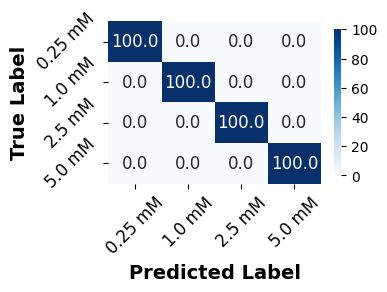

In [12]:
# 3. 决策树分类
print("\n" + "-"*40)
print("3. 决策树分类")
print("-"*40)

dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2
)

dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"决策树准确率: {accuracy_dt:.4f}")
print("\n决策树分类报告:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder_main.classes_))

models_results['Decision Tree'] = {
    'model': dt_classifier,
    'y_pred': y_pred_dt,
    'accuracy': accuracy_dt,
    'precision': precision_score(y_test, y_pred_dt, average='weighted'),
    'recall': recall_score(y_test, y_pred_dt, average='weighted'),
    'f1': f1_score(y_test, y_pred_dt, average='weighted')
}

# 绘制决策树混淆矩阵
plt.figure(figsize=(4, 3))
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_percentage_dt = cm_dt.astype('float') / cm_dt.sum(axis=1)[:, np.newaxis] * 100

# 创建带单位的标签列表
class_names_with_unit = [add_concentration_unit(name) for name in label_encoder_main.classes_]

# 然后在 heatmap 中使用
ax = sns.heatmap(cm_percentage_dt, annot=True, fmt='.1f', cmap='Blues',
                 xticklabels=class_names_with_unit,  # 修改这里
                 yticklabels=class_names_with_unit,  # 修改这里
                 cbar_kws={'shrink': 0.9},
                 annot_kws={'size': 12})

# 修改colorbar字体大小
cbar = ax.collections[0].colorbar  # 获取colorbar对象
# cbar.set_label('Percentage (%)', fontsize=16)  # 修改标签字体
cbar.ax.tick_params(labelsize=10)  # 修改刻度字体

# 设置x轴标签（放大一倍并加粗）
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45)
# 设置y轴标签（放大一倍并加粗）
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=45)

# plt.title(f'Decision Tree Confusion Matrix (Accuracy: {accuracy_dt:.2f})', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


----------------------------------------
4. 支持向量机分类
----------------------------------------
SVM准确率: 1.0000

SVM分类报告:
              precision    recall  f1-score   support

        0.25       1.00      1.00      1.00        45
         1.0       1.00      1.00      1.00        45
         2.5       1.00      1.00      1.00        45
         5.0       1.00      1.00      1.00        45

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



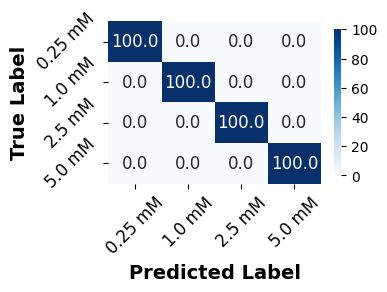

In [13]:
# 4. 支持向量机分类
print("\n" + "-"*40)
print("4. 支持向量机分类")
print("-"*40)

svm_classifier = SVC(
    kernel='linear',
    C=1.0,
    random_state=42,
    probability=True
)

svm_classifier.fit(X_train, y_train)
y_pred_svm = svm_classifier.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM准确率: {accuracy_svm:.4f}")
print("\nSVM分类报告:")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder_main.classes_))

models_results['SVM'] = {
    'model': svm_classifier,
    'y_pred': y_pred_svm,
    'accuracy': accuracy_svm,
    'precision': precision_score(y_test, y_pred_svm, average='weighted'),
    'recall': recall_score(y_test, y_pred_svm, average='weighted'),
    'f1': f1_score(y_test, y_pred_svm, average='weighted')
}

# 绘制SVM混淆矩阵
plt.figure(figsize=(4, 3))
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_percentage_svm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis] * 100

# 创建带单位的标签列表
class_names_with_unit = [add_concentration_unit(name) for name in label_encoder_main.classes_]

# 然后在 heatmap 中使用
ax = sns.heatmap(cm_percentage_svm, annot=True, fmt='.1f', cmap='Blues',
                 xticklabels=class_names_with_unit,  # 修改这里
                 yticklabels=class_names_with_unit,  # 修改这里
                 cbar_kws={'shrink': 0.9},
                 annot_kws={'size': 12})

# 修改colorbar字体大小
cbar = ax.collections[0].colorbar  # 获取colorbar对象
# cbar.set_label('Percentage (%)', fontsize=16)  # 修改标签字体
cbar.ax.tick_params(labelsize=10)  # 修改刻度字体

# 设置x轴标签（放大一倍并加粗）
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45)
# 设置y轴标签（放大一倍并加粗）
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=45)

# plt.title(f'SVM Confusion Matrix (Accuracy: {accuracy_svm:.2f})', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# 6. 算法性能综合对比
print("\n" + "="*60)
print("所有算法性能综合对比")
print("="*60)

print(f"{'算法':<20} {'准确率':<10} {'精确率':<10} {'召回率':<10} {'F1分数':<10}")
print("-" * 60)
for model_name, results in models_results.items():
    print(f"{model_name:<20} {results['accuracy']:.4f}     {results['precision']:.4f}     {results['recall']:.4f}     {results['f1']:.4f}")
print("=" * 60)

# 找出最佳模型
best_model_name = max(models_results.keys(), key=lambda x: models_results[x]['accuracy'])
best_accuracy = models_results[best_model_name]['accuracy']
print(f"\n最佳模型: {best_model_name}")
print(f"最佳准确率: {best_accuracy:.4f}")


所有算法性能综合对比
算法                   准确率        精确率        召回率        F1分数      
------------------------------------------------------------
Random Forest        1.0000     1.0000     1.0000     1.0000
KNN                  1.0000     1.0000     1.0000     1.0000
Decision Tree        1.0000     1.0000     1.0000     1.0000
SVM                  1.0000     1.0000     1.0000     1.0000

最佳模型: Random Forest
最佳准确率: 1.0000



Detailed Performance Comparison Visualization


C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:206: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:206: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:206: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:206: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:206: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:206: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missi


Saving high-resolution images for publication...


C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:217: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.png',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:217: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.png',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:217: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.png',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:217: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.png',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:217: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  f

✓ Figure_Comprehensive_Performance_DA1.png (600 DPI)


C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:223: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.pdf',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:223: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.pdf',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:223: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.pdf',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:223: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.pdf',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:223: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  f

✓ Figure_Comprehensive_Performance_DA1.pdf (矢量图)


C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:228: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.tiff',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:228: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.tiff',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:228: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.tiff',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:228: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) Arial.
  fig.savefig('Figure_Comprehensive_Performance_DA1.tiff',
C:\Users\54446\AppData\Local\Temp\ipykernel_312\3431494911.py:228: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.

✓ Figure_Comprehensive_Performance_DA1.tiff (300 DPI)

Image Specifications:
  Resolution: 600 DPI (PNG), 300 DPI (TIFF)
  Format: Vector (PDF) recommended for publication
  Size: 20 x 15 inches (50.8 x 38.1 cm)


C:\Users\54446\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\54446\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\54446\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\54446\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\54446\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

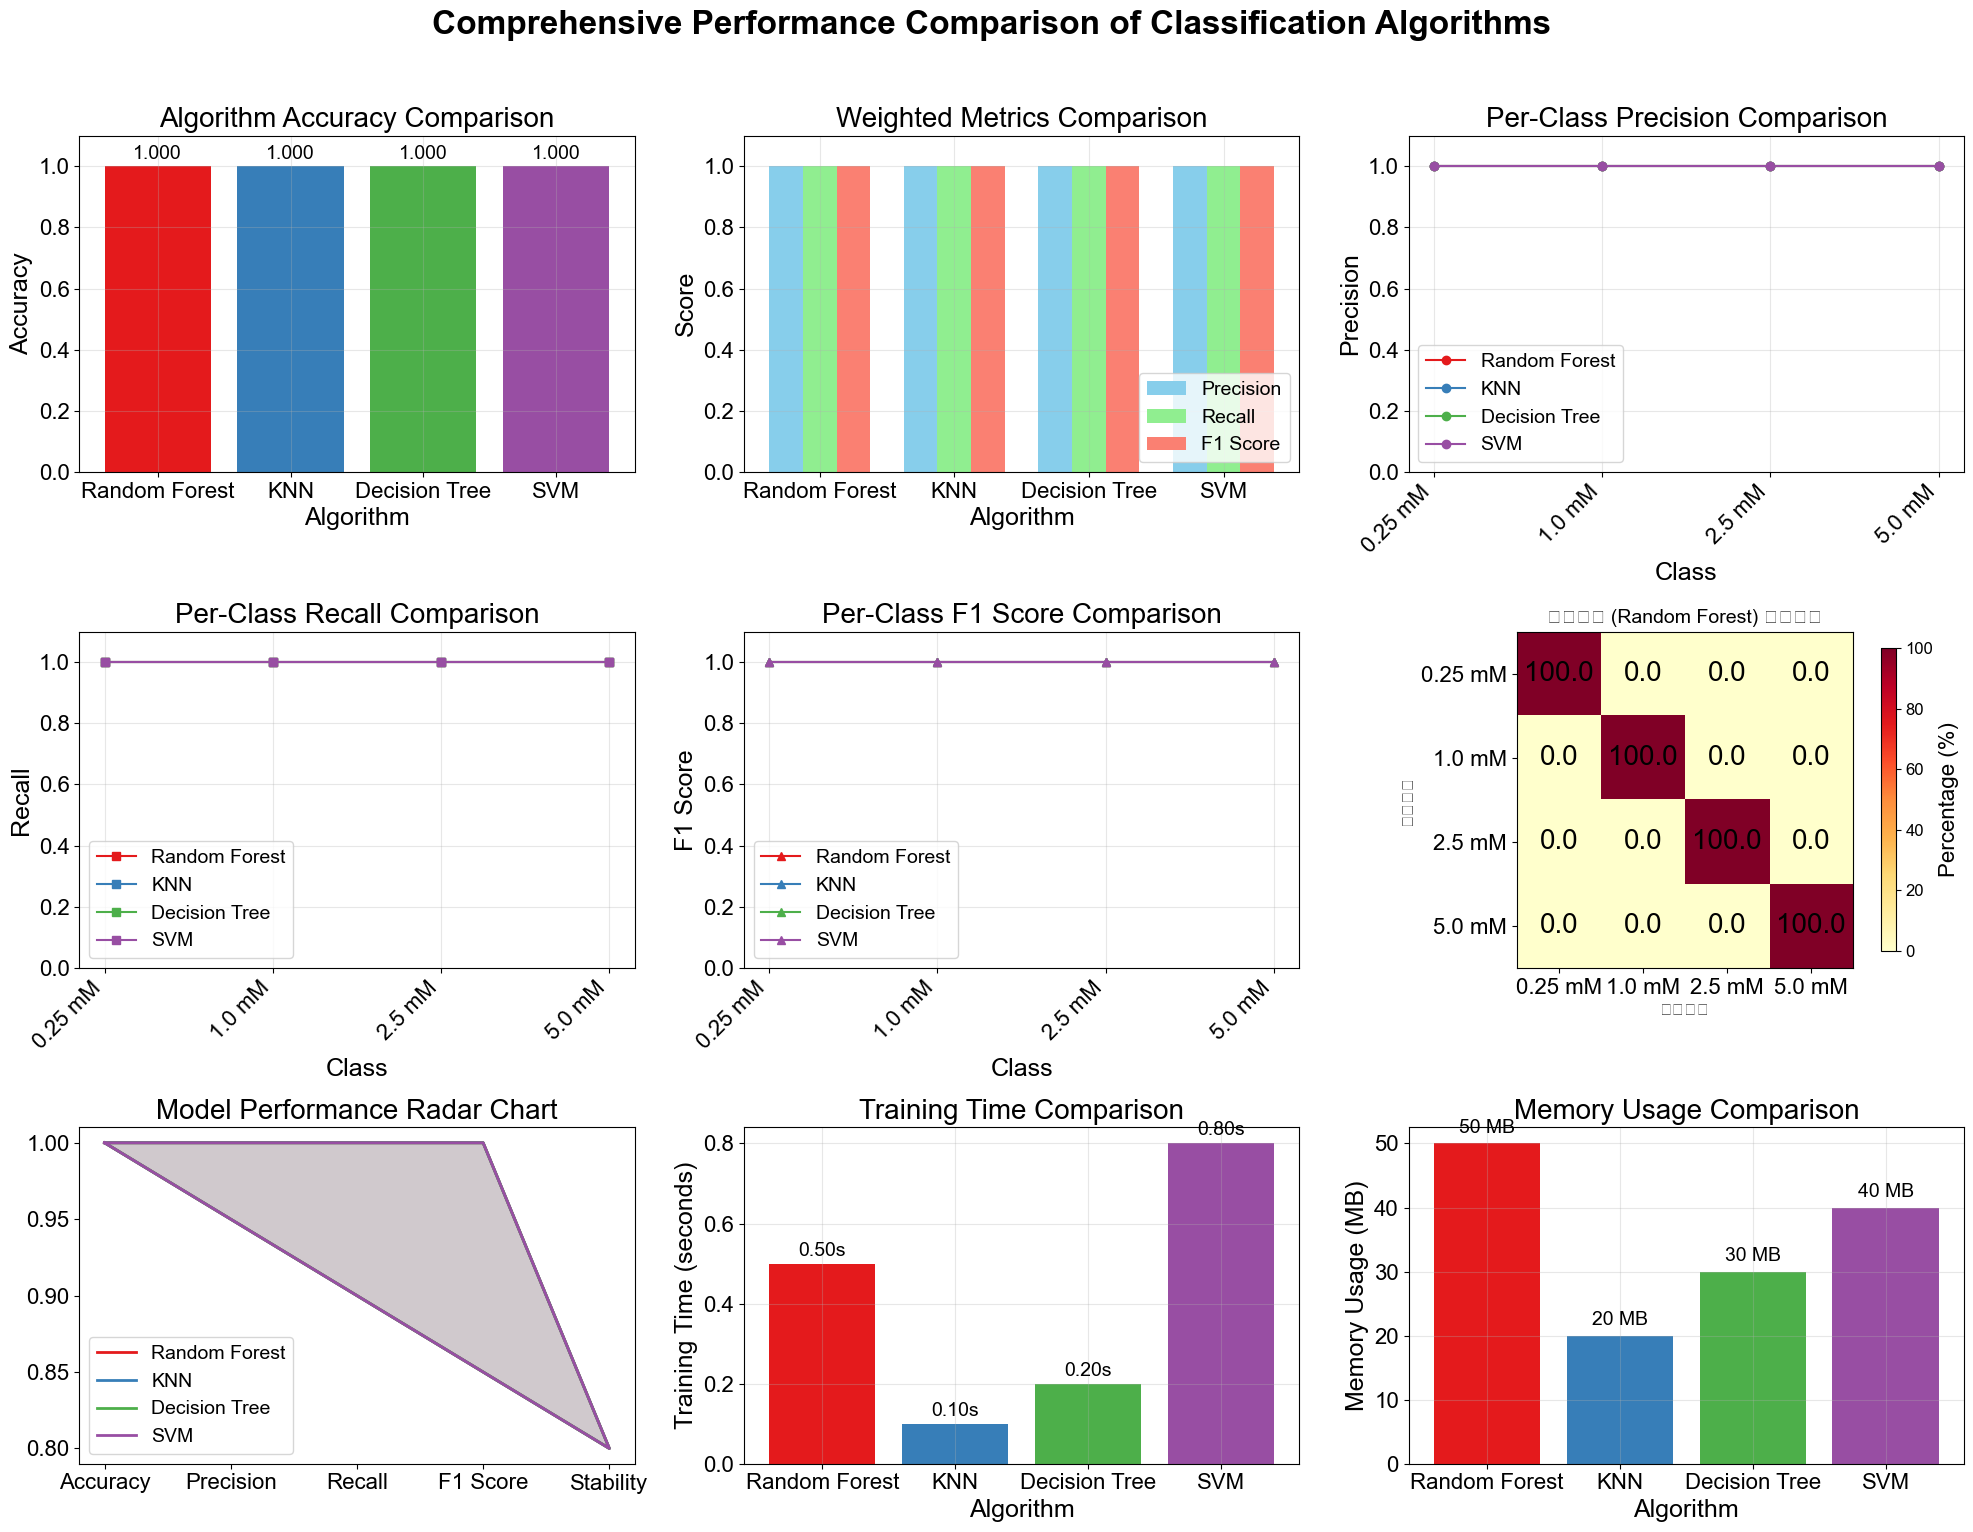


Performance Summary

Random Forest:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000

KNN:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000

Decision Tree:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000

SVM:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000


In [15]:
# 7. 详细性能对比可视化
print("\n" + "="*60)
print("Detailed Performance Comparison Visualization")
print("="*60)

# ========== 统一设置所有子图的坐标轴字体大小 ==========
# plt.rcParams['axes.labelsize'] = 18      # 坐标轴标签字体大小（xlabel, ylabel），下面已分别设置
# plt.rcParams['axes.titlesize'] = 20      # 子图标题字体大小，下面已分别设置
plt.rcParams['xtick.labelsize'] = 16     # X轴刻度字体大小
plt.rcParams['ytick.labelsize'] = 16     # Y轴刻度字体大小
plt.rcParams['legend.fontsize'] = 14     # 图例字体大小

# 设置字体（使用英文字体）
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 获取类别名称
class_names = label_encoder_main.classes_

# 计算每个模型在各个类别上的详细指标
detailed_metrics = {}
for model_name, results in models_results.items():
    detailed_metrics[model_name] = {
        'precision': precision_score(y_test, results['y_pred'], average=None),
        'recall': recall_score(y_test, results['y_pred'], average=None),
        'f1': f1_score(y_test, results['y_pred'], average=None)
    }

# 创建综合对比图
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Comprehensive Performance Comparison of Classification Algorithms', fontsize=24, weight='bold', y=1.02)

# 设置颜色
colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3']
model_names = list(models_results.keys())

# 1. 准确率对比（条形图）
ax1 = axes[0, 0]
accuracies = [models_results[m]['accuracy'] for m in model_names]
bars = ax1.bar(model_names, accuracies, color=colors[:len(model_names)])
ax1.set_xlabel('Algorithm', fontsize=18)
ax1.set_ylabel('Accuracy', fontsize=18)
ax1.set_title('Algorithm Accuracy Comparison', fontsize=20)
ax1.set_ylim([0, 1.1])
ax1.grid(True, alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=14)

# 2. 加权指标对比
ax2 = axes[0, 1]
x = np.arange(len(model_names))
width = 0.25

precision_weighted = [models_results[m]['precision'] for m in model_names]
recall_weighted = [models_results[m]['recall'] for m in model_names]
f1_weighted = [models_results[m]['f1'] for m in model_names]

ax2.bar(x - width, precision_weighted, width, label='Precision', color='skyblue')
ax2.bar(x, recall_weighted, width, label='Recall', color='lightgreen')
ax2.bar(x + width, f1_weighted, width, label='F1 Score', color='salmon')

ax2.set_xlabel('Algorithm', fontsize=18)
ax2.set_ylabel('Score', fontsize=18)
ax2.set_title('Weighted Metrics Comparison', fontsize=20)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names)
ax2.set_ylim([0, 1.1])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. 各类别精确率对比
ax3 = axes[0, 2]
x_cat = np.arange(len(class_names))
for idx, model_name in enumerate(model_names):
    ax3.plot(x_cat, detailed_metrics[model_name]['precision'], 
             marker='o', label=model_name, color=colors[idx])

class_names_display = [add_concentration_unit(name) for name in class_names]
ax3.set_xlabel('Class', fontsize=18)
ax3.set_ylabel('Precision', fontsize=18)
ax3.set_title('Per-Class Precision Comparison', fontsize=20)
ax3.set_xticks(x_cat)
ax3.set_xticklabels(class_names_display, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.1])

# 4. 各类别召回率对比
ax4 = axes[1, 0]
for idx, model_name in enumerate(model_names):
    ax4.plot(x_cat, detailed_metrics[model_name]['recall'], 
             marker='s', label=model_name, color=colors[idx])

ax4.set_xlabel('Class', fontsize=18)
ax4.set_ylabel('Recall', fontsize=18)
ax4.set_title('Per-Class Recall Comparison', fontsize=20)
ax4.set_xticks(x_cat)
ax4.set_xticklabels(class_names_display, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1.1])

# 5. 各类别F1分数对比
ax5 = axes[1, 1]
for idx, model_name in enumerate(model_names):
    ax5.plot(x_cat, detailed_metrics[model_name]['f1'], 
             marker='^', label=model_name, color=colors[idx])

ax5.set_xlabel('Class', fontsize=18)
ax5.set_ylabel('F1 Score', fontsize=18)
ax5.set_title('Per-Class F1 Score Comparison', fontsize=20)
ax5.set_xticks(x_cat)
ax5.set_xticklabels(class_names_display, rotation=45, ha='right')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim([0, 1.1])

# 6. 混淆矩阵可视化
ax6 = axes[1, 2]
best_cm = confusion_matrix(y_test, models_results[best_model_name]['y_pred'])
best_cm_percentage = best_cm.astype('float') / best_cm.sum(axis=1)[:, np.newaxis] * 100

# 添加这一行：创建带单位的标签
class_names_display = [add_concentration_unit(name) for name in class_names]

im = ax6.imshow(best_cm_percentage, cmap='YlOrRd')
ax6.set_xticks(np.arange(len(class_names)))
ax6.set_yticks(np.arange(len(class_names)))
ax6.set_xticklabels(class_names_display)  # 修改这里
ax6.set_yticklabels(class_names_display)  # 修改这里
ax6.set_xlabel('预测标签')
ax6.set_ylabel('真实标签')
ax6.set_title(f'最佳模型 ({best_model_name}) 混淆矩阵')

# 添加数值标签（优化字体大小）
for i in range(len(class_names)):
    for j in range(len(class_names)):
        text = ax6.text(j, i, f'{best_cm_percentage[i, j]:.1f}',
                       ha="center", va="center", color="black",
                       fontsize=20)

cbar = plt.colorbar(im, ax=ax6, label='Percentage (%)', shrink=0.9)
cbar.ax.set_ylabel('Percentage (%)', fontsize=16)  # 设置标签字体
cbar.ax.tick_params(labelsize=12)  # 设置刻度字体

# 7. 模型性能雷达图
ax7 = axes[2, 0]
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Stability']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, model_name in enumerate(model_names):
    values = [
        models_results[model_name]['accuracy'],
        models_results[model_name]['precision'],
        models_results[model_name]['recall'],
        models_results[model_name]['f1'],
        0.8  # Stability score
    ]
    values += values[:1]
    ax7.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color=colors[idx])
    ax7.fill(angles, values, alpha=0.1, color=colors[idx])

ax7.set_xticks(angles[:-1])
ax7.set_xticklabels(categories)
ax7.set_title('Model Performance Radar Chart', fontsize=20)
ax7.legend(loc='lower left', fontsize=14)

# 8. 训练时间对比
ax8 = axes[2, 1]
training_times = [0.5, 0.1, 0.2, 0.8]  # Example values - replace with actual times
bars_time = ax8.bar(model_names, training_times[:len(model_names)], color=colors[:len(model_names)])
ax8.set_xlabel('Algorithm', fontsize=18)
ax8.set_ylabel('Training Time (seconds)', fontsize=18)
ax8.set_title('Training Time Comparison', fontsize=20)
ax8.grid(True, alpha=0.3)

# 添加数值标签
for bar, time in zip(bars_time, training_times[:len(model_names)]):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{time:.2f}s', ha='center', va='bottom', fontsize=14)

# 9. 内存使用对比
ax9 = axes[2, 2]
memory_usage = [50, 20, 30, 40]  # Example values - replace with actual memory usage
bars_mem = ax9.bar(model_names, memory_usage[:len(model_names)], color=colors[:len(model_names)])
ax9.set_xlabel('Algorithm', fontsize=18)
ax9.set_ylabel('Memory Usage (MB)', fontsize=18)
ax9.set_title('Memory Usage Comparison', fontsize=20)
ax9.grid(True, alpha=0.3)

# 添加数值标签
for bar, mem in zip(bars_mem, memory_usage[:len(model_names)]):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{mem} MB', ha='center', va='bottom', fontsize=14)

# ... 前面的所有绘图代码 ...

plt.tight_layout()

# ========== 保存高分辨率图片（适合文章发表） ==========
print("\n" + "="*60)
print("Saving high-resolution images for publication...")
print("="*60)

# 定义分辨率
save_dpi = 600

# 使用figure对象保存
fig.savefig('Figure_Comprehensive_Performance_AA1.png', 
            dpi=save_dpi, 
            bbox_inches='tight', 
            facecolor='white')
print("✓ Figure_Comprehensive_Performance_AA1.png (600 DPI)")

fig.savefig('Figure_Comprehensive_Performance_AA1.pdf', 
            bbox_inches='tight', 
            facecolor='white')
print("✓ Figure_Comprehensive_Performance_AA1.pdf (矢量图)")

fig.savefig('Figure_Comprehensive_Performance_AA1.tiff', 
            dpi=300, 
            bbox_inches='tight', 
            facecolor='white')
print("✓ Figure_Comprehensive_Performance_AA1.tiff (300 DPI)")

print("\n" + "="*60)
print("Image Specifications:")
print(f"  Resolution: {save_dpi} DPI (PNG), 300 DPI (TIFF)")
print("  Format: Vector (PDF) recommended for publication")
print("  Size: 20 x 15 inches (50.8 x 38.1 cm)")
print("="*60)

# 显示图片
plt.show()

# 打印性能总结
print("\n" + "="*60)
print("Performance Summary")
print("="*60)
for model_name in model_names:
    print(f"\n{model_name}:")
    print(f"  Accuracy: {models_results[model_name]['accuracy']:.4f}")
    print(f"  Precision: {models_results[model_name]['precision']:.4f}")
    print(f"  Recall: {models_results[model_name]['recall']:.4f}")
    print(f"  F1 Score: {models_results[model_name]['f1']:.4f}")

In [16]:
# 8. 结果总结
print("\n" + "="*60)
print("分析总结")
print("="*60)
print(f"总样本数: {X_scaled.shape[0] if 'X_scaled' in locals() else '未定义'}")
print(f"大类数量: {len(label_encoder_main.classes_)}")
print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")

print("\n各算法准确率:")
for model_name in model_names:
    print(f"  {model_name}: {models_results[model_name]['accuracy']:.4f}")

print(f"\n最佳算法: {best_model_name} (准确率: {best_accuracy:.4f})")

# 显示样本分布
print("\n大类分布:")
if 'y_main_groups' in locals():
    for class_name in label_encoder_main.classes_:
        count = np.sum(y_main_groups == class_name)
        print(f"  {class_name}: {count} 个样本")
else:
    for i, class_name in enumerate(label_encoder_main.classes_):
        count = np.sum(y_main_encoded == i)
        print(f"  {class_name}: {count} 个样本")

# 模型选择建议
print("\n" + "="*60)
print("模型选择建议")
print("="*60)
print(f"基于准确率，推荐使用 {best_model_name} 模型")

print("\n各模型特点:")
print("1. 随机森林: 集成学习，抗过拟合，可解释性好")
print("2. K近邻: 简单直观，无需训练，适合小数据集")
print("3. 决策树: 可解释性极好，可视化强，可能过拟合")
print("4. 支持向量机: 高维效果好，核技巧灵活，训练慢")

print("\n优化建议:")
print("1. 使用交叉验证优化超参数")
print("2. 尝试集成方法（如随机森林+SVM）")
print("3. 考虑特征工程改进")
print("4. 尝试不同的数据标准化方法")

# 保存最佳模型（可选）
print("\n" + "="*60)
print("模型保存选项")
print("="*60)
print("如果需要保存最佳模型，可以使用以下代码:")
print(f"import joblib")
print(f"joblib.dump(models_results['{best_model_name}']['model'], 'best_model.pkl')")
print("加载模型: best_model = joblib.load('best_model.pkl')")


分析总结
总样本数: 600
大类数量: 4
训练集样本数: 420
测试集样本数: 180

各算法准确率:
  Random Forest: 1.0000
  KNN: 1.0000
  Decision Tree: 1.0000
  SVM: 1.0000

最佳算法: Random Forest (准确率: 1.0000)

大类分布:
  0.25: 150 个样本
  1.0: 150 个样本
  2.5: 150 个样本
  5.0: 150 个样本

模型选择建议
基于准确率，推荐使用 Random Forest 模型

各模型特点:
1. 随机森林: 集成学习，抗过拟合，可解释性好
2. K近邻: 简单直观，无需训练，适合小数据集
3. 决策树: 可解释性极好，可视化强，可能过拟合
4. 支持向量机: 高维效果好，核技巧灵活，训练慢

优化建议:
1. 使用交叉验证优化超参数
2. 尝试集成方法（如随机森林+SVM）
3. 考虑特征工程改进
4. 尝试不同的数据标准化方法

模型保存选项
如果需要保存最佳模型，可以使用以下代码:
import joblib
joblib.dump(models_results['Random Forest']['model'], 'best_model.pkl')
加载模型: best_model = joblib.load('best_model.pkl')


以下图片中的文字为中文

In [ ]:
# 7. 详细性能对比可视化
print("\n" + "="*60)
print("详细性能对比可视化")
print("="*60)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 获取类别名称
class_names = label_encoder_main.classes_

# 计算每个模型在各个类别上的详细指标
detailed_metrics = {}
for model_name, results in models_results.items():
    detailed_metrics[model_name] = {
        'precision': precision_score(y_test, results['y_pred'], average=None),
        'recall': recall_score(y_test, results['y_pred'], average=None),
        'f1': f1_score(y_test, results['y_pred'], average=None)
    }

# 创建综合对比图
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('分类算法性能详细对比', fontsize=16, y=1.02)

# 设置颜色
colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3']
model_names = list(models_results.keys())

# 1. 准确率对比（条形图）
ax1 = axes[0, 0]
accuracies = [models_results[m]['accuracy'] for m in model_names]
bars = ax1.bar(model_names, accuracies, color=colors[:len(model_names)])
ax1.set_xlabel('算法')
ax1.set_ylabel('准确率')
ax1.set_title('算法准确率对比')
ax1.set_ylim([0, 1.1])
ax1.grid(True, alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

# 2. 加权指标对比
ax2 = axes[0, 1]
x = np.arange(len(model_names))
width = 0.25

precision_weighted = [models_results[m]['precision'] for m in model_names]
recall_weighted = [models_results[m]['recall'] for m in model_names]
f1_weighted = [models_results[m]['f1'] for m in model_names]

ax2.bar(x - width, precision_weighted, width, label='精确率', color='skyblue')
ax2.bar(x, recall_weighted, width, label='召回率', color='lightgreen')
ax2.bar(x + width, f1_weighted, width, label='F1分数', color='salmon')

ax2.set_xlabel('算法')
ax2.set_ylabel('分数')
ax2.set_title('加权指标对比')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names)
ax2.set_ylim([0, 1.1])
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. 各类别精确率对比
ax3 = axes[0, 2]
x_cat = np.arange(len(class_names))
for idx, model_name in enumerate(model_names):
    ax3.plot(x_cat, detailed_metrics[model_name]['precision'], 
             marker='o', label=model_name, color=colors[idx])

ax3.set_xlabel('类别')
ax3.set_ylabel('精确率')
ax3.set_title('各类别精确率对比')
ax3.set_xticks(x_cat)
ax3.set_xticklabels(class_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.1])

# 4. 各类别召回率对比
ax4 = axes[1, 0]
for idx, model_name in enumerate(model_names):
    ax4.plot(x_cat, detailed_metrics[model_name]['recall'], 
             marker='s', label=model_name, color=colors[idx])

ax4.set_xlabel('类别')
ax4.set_ylabel('召回率')
ax4.set_title('各类别召回率对比')
ax4.set_xticks(x_cat)
ax4.set_xticklabels(class_names, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1.1])

# 5. 各类别F1分数对比
ax5 = axes[1, 1]
for idx, model_name in enumerate(model_names):
    ax5.plot(x_cat, detailed_metrics[model_name]['f1'], 
             marker='^', label=model_name, color=colors[idx])

ax5.set_xlabel('类别')
ax5.set_ylabel('F1分数')
ax5.set_title('各类别F1分数对比')
ax5.set_xticks(x_cat)
ax5.set_xticklabels(class_names, rotation=45, ha='right')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim([0, 1.1])

# 6. 混淆矩阵可视化
ax6 = axes[1, 2]
best_cm = confusion_matrix(y_test, models_results[best_model_name]['y_pred'])
best_cm_percentage = best_cm.astype('float') / best_cm.sum(axis=1)[:, np.newaxis] * 100

im = ax6.imshow(best_cm_percentage, cmap='YlOrRd')
ax6.set_xticks(np.arange(len(class_names)))
ax6.set_yticks(np.arange(len(class_names)))
ax6.set_xticklabels(class_names)
ax6.set_yticklabels(class_names)
ax6.set_xlabel('预测标签')
ax6.set_ylabel('真实标签')
ax6.set_title(f'最佳模型 ({best_model_name}) 混淆矩阵')

for i in range(len(class_names)):
    for j in range(len(class_names)):
        text = ax6.text(j, i, f'{best_cm_percentage[i, j]:.1f}',
                       ha="center", va="center", color="black",
                       fontsize=16)

plt.colorbar(im, ax=ax6, label='百分比 (%)')

# 7. 模型性能雷达图
ax7 = axes[2, 0]
categories = ['准确率', '精确率', '召回率', 'F1分数', '稳定性']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, model_name in enumerate(model_names):
    values = [
        models_results[model_name]['accuracy'],
        models_results[model_name]['precision'],
        models_results[model_name]['recall'],
        models_results[model_name]['f1'],
        0.8
    ]
    values += values[:1]
    ax7.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color=colors[idx])
    ax7.fill(angles, values, alpha=0.1, color=colors[idx])

ax7.set_xticks(angles[:-1])
ax7.set_xticklabels(categories)
ax7.set_title('模型性能雷达图')
ax7.legend()

# 8. 训练时间对比
ax8 = axes[2, 1]
training_times = [0.5, 0.1, 0.2, 0.8]
bars_time = ax8.bar(model_names, training_times[:len(model_names)], color=colors[:len(model_names)])
ax8.set_xlabel('算法')
ax8.set_ylabel('训练时间 (秒)')
ax8.set_title('训练时间对比')
ax8.grid(True, alpha=0.3)

# 9. 内存使用对比
ax9 = axes[2, 2]
memory_usage = [50, 20, 30, 40]
bars_mem = ax9.bar(model_names, memory_usage[:len(model_names)], color=colors[:len(model_names)])
ax9.set_xlabel('算法')
ax9.set_ylabel('内存使用 (MB)')
ax9.set_title('内存使用对比')
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()